In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

plt.rcParams["figure.figsize"] = (13, 6)

In [2]:
tsla = pd.read_csv("../data/processed/TSLA_cleaned.csv", index_col=0, parse_dates=True)
close = tsla["Close"].dropna()
print(f"TSLA close price series: {len(close)} rows, {close.index.min().date()} -> {close.index.max().date()}")
close.tail()

TSLA close price series: 2998 rows, 2015-01-02 -> 2026-06-30


2026-06-24    375.529999
2026-06-25    375.119995
2026-06-26    379.709991
2026-06-29    411.839996
2026-06-30    411.839996
Name: Close, dtype: float64

In [3]:
SPLIT_DATE = "2025-01-01"

train = close[close.index < SPLIT_DATE]
test = close[close.index >= SPLIT_DATE]

print(f"Train: {len(train)} rows ({train.index.min().date()} -> {train.index.max().date()})")
print(f"Test:  {len(test)} rows ({test.index.min().date()} -> {test.index.max().date()})")

Train: 2608 rows (2015-01-02 -> 2024-12-31)
Test:  390 rows (2025-01-01 -> 2026-06-30)


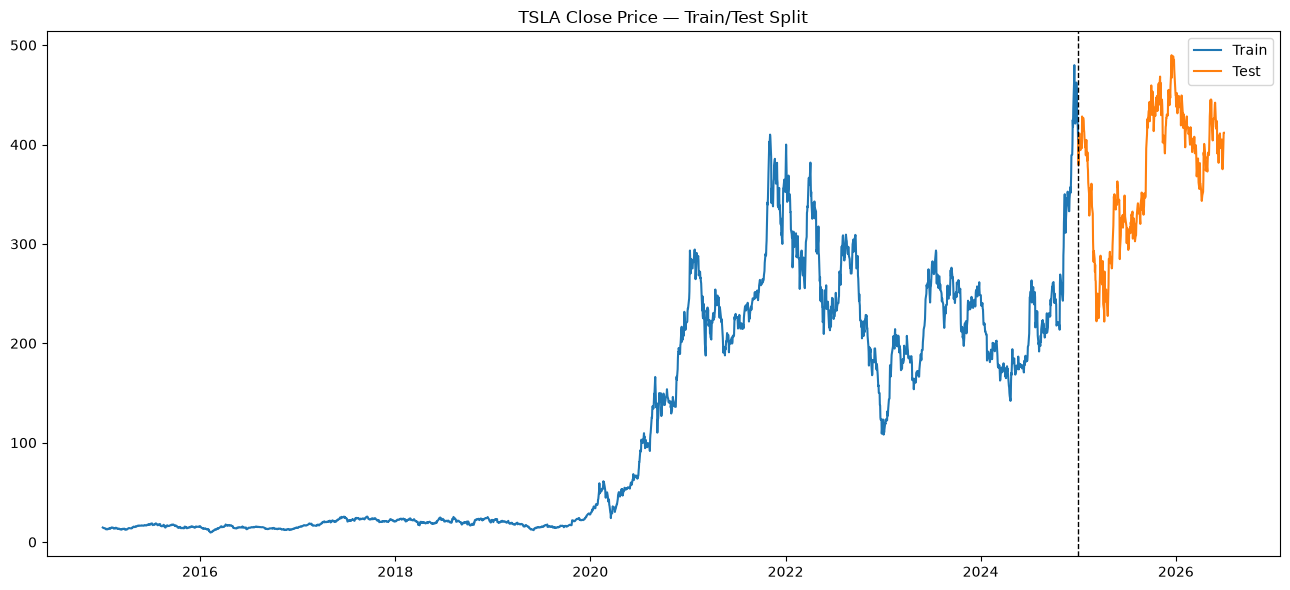

In [4]:
fig, ax = plt.subplots()
ax.plot(train.index, train, label="Train")
ax.plot(test.index, test, label="Test")
ax.axvline(pd.Timestamp(SPLIT_DATE), color="black", linestyle="--", linewidth=1) # type: ignore
ax.set_title("TSLA Close Price — Train/Test Split")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_task2_train_test_split.png", dpi=120)
plt.show()

In [5]:
model = pm.auto_arima(
    train,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    trace=True,
)

print("\nSelected order (p, d, q):", model.order)
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16873.591, Time=0.20 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.25 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16873.127, Time=0.17 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16877.541, Time=0.35 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.318 seconds

Selected order (p, d, q): (0, 1, 0)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2608
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8435.563
Date:                Mon, 06 Jul 2026   AIC                          16873.127
Time:                        10:53:22   BIC                          16878.993
Sample:                    01-02-2015   HQIC                         16875.252
                         - 12-31-2

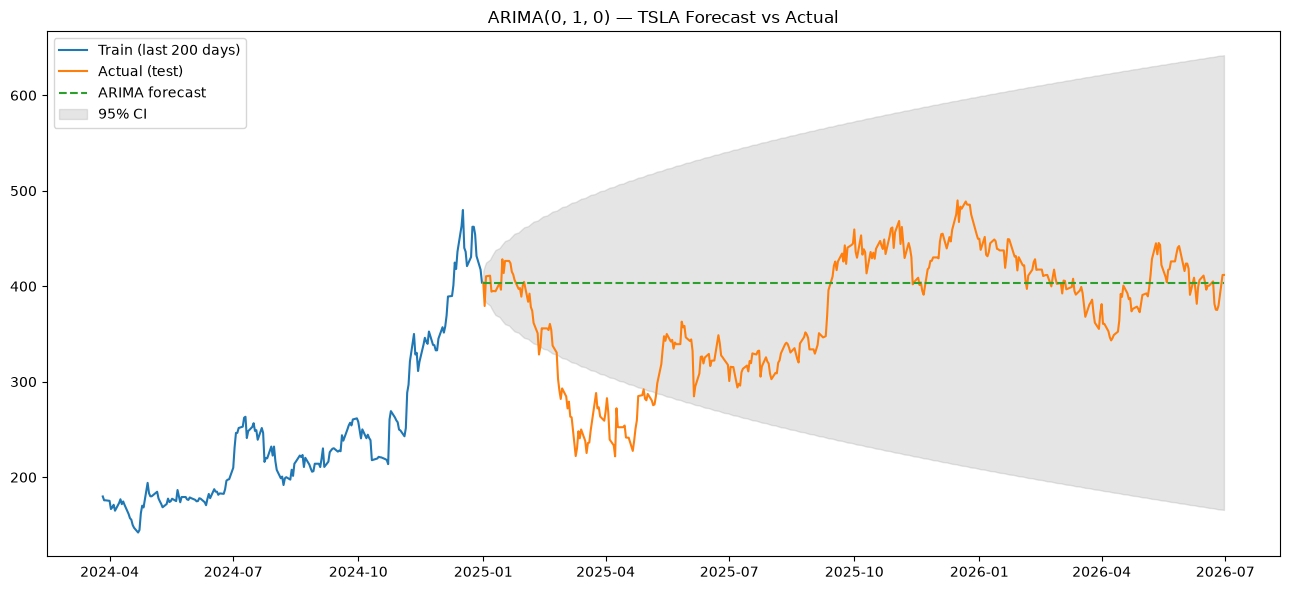

In [6]:
n_periods = len(test)
forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)
forecast = pd.Series(forecast, index=test.index)
lower = pd.Series(conf_int[:, 0], index=test.index)
upper = pd.Series(conf_int[:, 1], index=test.index)

fig, ax = plt.subplots()
ax.plot(train.index[-200:], train[-200:], label="Train (last 200 days)")
ax.plot(test.index, test, label="Actual (test)")
ax.plot(forecast.index, forecast, label="ARIMA forecast", linestyle="--")
ax.fill_between(forecast.index, lower, upper, color="gray", alpha=0.2, label="95% CI")
ax.set_title(f"ARIMA{model.order} — TSLA Forecast vs Actual")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_task2_arima_forecast.png", dpi=120)
plt.show()

In [7]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test.values - forecast.values) / test.values)) * 100 # type: ignore

arima_metrics = pd.DataFrame(
    {"MAE": [mae], "RMSE": [rmse], "MAPE (%)": [mape]},
    index=[f"ARIMA{model.order}"],
)
print(arima_metrics.round(3))

arima_metrics.to_csv("../data/processed/arima_metrics.csv")
forecast.to_csv("../data/processed/arima_forecast.csv")

                   MAE    RMSE  MAPE (%)
ARIMA(0, 1, 0)  54.034  70.108    17.073
